# Assignment 1
Fazile Brahimi

## General information

Please give short (2-3 sentences) interpretations / explanations to your answers, not only the program code and outputs. Be concise and focused, especially in the AI-world. We take this seriously and will downgrade excessive verbosity.

Grades will be distributed with the following rule: from the points you earn, you get 100% if you submit until the due date (**2026-02-25 12:00 CET**), 50% within 24 hours past due date, and 0% after that.

## Task 1: Gene expression data (3 points)

From the ISLR website, we can download a **gene expression data** set (`Ch10Ex11.csv`) that consists of 40 tissue samples with measurements on 1,000 genes. The first 20 samples are from healthy patients, while the second 20 are from a diseased group.

We would have no chance to estimate any model on these 1,000 features. However, we could reduce the dimensionality with PCA. Then, we could look at the relation of the first few principal components (that captures part of the variance of all 1,000 features) and the outcome.

Note that as we only have 40 observations we can only define a subspace with at most 39 dimensions. Think of it like trying to define a volume in 3D space using only 2 points - you can only define a line, not a full 3D space. Technically, the sklearn PCA implementation will result in 40 components, but the last one will have a variance of 0.

In [18]:
# Load the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Read the CSV file
url = 'https://www.statlearning.com/s/Ch10Ex11.csv'
genes = pd.read_csv(url, header=None)

# Transpose the dataframe and convert to pandas DataFrame
genes = genes.T
genes = pd.DataFrame(genes)
print('Dimensions of genes dataframe:', genes.shape)

# Define health_status
health_status = ['healthy'] * 20 + ['diseased'] * 20

Dimensions of genes dataframe: (40, 1000)


<div style="page-break-after: always"></div>

### Questions

1. Compute the variance of each feature and plot a histogram of those variances. Based on the histogram, are the features similarly scaled? Would you standardize the features before applying PCA? Explain your reasoning. (*Hint*: treat features as similarly scaled if their variances differ by at most an order of magnitude.)

2. Apply PCA to the full dataset. How many principal components are required to explain at least 90\% of the total variance? How much variance is captured by the first two principal components?

3. Create a scatter plot of the first two component scores (the data projected onto the first two principal components). Color the points by patient health status. Do these components help distinguish healthy from diseased patients? Which component separates the groups more clearly?

4. For the principal component that best separates healthy and diseased patients, identify the genes with the largest absolute loadings (the strongest contributors). Briefly describe how you selected them. (*Hint*: examine the component loadings.)

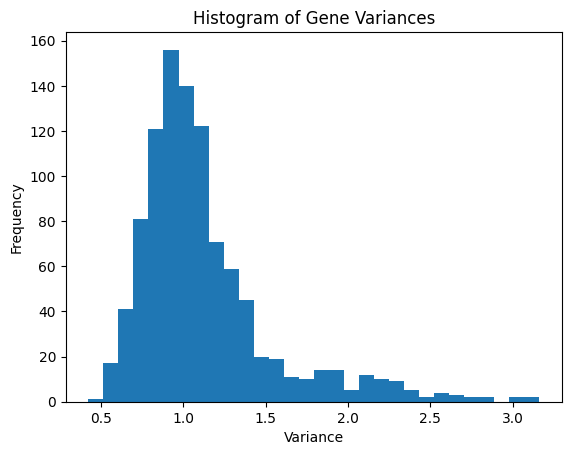

Min variance: 0.4229843598212085
Max variance: 3.1610329345826025


In [ ]:
1. # Compute variance of each gene (column)
variances = genes.var(axis=0)

# Plot histogram
plt.hist(variances, bins=30)
plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.title("Histogram of Gene Variances")
plt.show()

# Print summary
print("Min variance:", variances.min())
print("Max variance:", variances.max())

1. The gene variances range from about 0.42 to 3.16, which means the largest variance is less than ten times the smallest one. Since the features differ by less than one order of magnitude, they can be considered similarly scaled. Because PCA is sensitive to feature scale and no gene strongly dominates in terms of variance, I would not standardize the data before applying PCA.

In [ ]:
# Apply PCA to original data (not scaled)
pca = PCA()
pca.fit(genes)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Number of components needed for 90%
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("Components needed for 90% variance:", n_components_90)
print("Variance explained by PC1:", explained_variance_ratio[0])
print("Variance explained by PC2:", explained_variance_ratio[1])
print("Variance explained by PC1 + PC2:", explained_variance_ratio[0] + explained_variance_ratio[1])

Components needed for 90% variance: 33
Variance explained by PC1: 0.1266765388810989
Variance explained by PC2: 0.03271437898183046
Variance explained by PC1 + PC2: 0.15939091786292936


2. A total of 33 principal components are needed to explain at least 90% of the total variance. The first principal component explains about 12.7% of the variance, and the second explains about 3.3%, meaning the first two together capture roughly 15.9%. This shows that the variation in gene expression is spread across many components rather than being concentrated in just the first few.

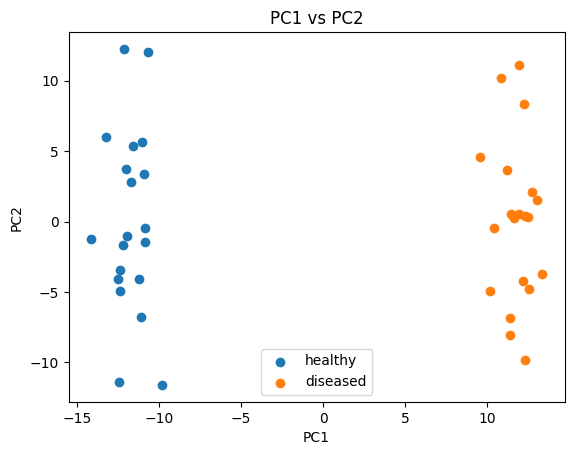

In [5]:
# Project data onto principal components
scores = pca.transform(genes)

health_status = ['healthy'] * 20 + ['diseased'] * 20

import matplotlib.pyplot as plt

plt.figure()

for label in ['healthy', 'diseased']:
    idx = [i for i, h in enumerate(health_status) if h == label]
    plt.scatter(scores[idx, 0], scores[idx, 1], label=label)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2")
plt.legend()
plt.show()

3. The scatter plot of the first two principal components shows a clear separation between healthy and diseased patients. Healthy samples cluster at negative values of PC1, while diseased samples cluster at positive values, with almost no overlap. This indicates that the first two components, especially PC1, help distinguish between the groups. PC1 provides the clearest separation, whereas PC2 mainly captures variation within each group rather than between them.

In [6]:
# Loadings matrix (rows = PCs, columns = genes)
loadings = pca.components_

# PC1 loadings
pc1_loadings = loadings[0]

# Absolute values
abs_loadings = np.abs(pc1_loadings)

# Get indices of top 10 genes
top_genes_idx = np.argsort(abs_loadings)[-10:]

print("Top 10 contributing gene indices:", top_genes_idx)
print("Corresponding loadings:", pc1_loadings[top_genes_idx])

Top 10 contributing gene indices: [598 528 567 564 581 501 539 548 583 599]
Corresponding loadings: [0.10382067 0.10416318 0.10618761 0.10627118 0.10654939 0.10745956
 0.10812548 0.10832937 0.11039835 0.11424303]


4. Since PC1 provides the clearest separation between healthy and diseased patients, we examined its loadings to identify the strongest contributing genes. We selected the genes with the largest absolute loadings, as the magnitude of a loading indicates how strongly a gene contributes to the principal component. The top contributing genes were those with indices 598, 528, 567, 564, 581, 501, 539, 548, 583, and 599, which have the highest absolute loading values and therefore drive most of the separation captured by PC1.

## Task 2: PCA on simulated data (3 points)

In this exercise, you will work on simulated features. This simulated data have **mixed correlation structure**: some features cluster together (correlated), while others are independent.

In [ ]:
# Data generation with mixed correlation structure
rng = np.random.default_rng(seed=20260218)  # for reproducibility
n = 100
p = 50

# Create 5 groups of 10 correlated features each
# Within each group, features are correlated with each other
# Between groups, features are independent

X = np.zeros((n, p))

# Generate 5 independent latent factors (one per group)
n_groups = 5
features_per_group = 10
latent_factors = rng.normal(loc=0.0, scale=1.0, size=(n, n_groups))

for group in range(n_groups):
    start_idx = group * features_per_group
    end_idx = start_idx + features_per_group
    
    # Each feature in the group is the latent factor plus independent noise
    # This creates correlation within the group
    for i in range(features_per_group):
        noise = rng.normal(loc=0.0, scale=0.5, size=n)  # smaller noise = higher correlation
        X[:, start_idx + i] = latent_factors[:, group] + noise

print(f'Generated data shape: {X.shape}')
print(f'Data structure: {n_groups} groups of {features_per_group} correlated features each')

Generated data shape: (100, 50)
Data structure: 5 groups of 10 correlated features each


### Questions

1. Compute the correlation matrix of the generated features and visualize it as a heatmap. Describe the correlation structure you observe. Does it match the data-generating process?

2. Run PCA on the full dataset (100 samples, 50 features). How many components are needed to explain at least 90% of the variance? 

3. Plot the explained variance ratio for the first 20 components. What does the shape of this curve tell you about the data structure? (*Hint*: look for an "elbow" or plateaus in the curve.)

4. Split the data into 80–20% train/test sets. For a range of component counts, compute reconstruction errors on both sets like we did in class. Plot these errors. Based on the plot, how many components would you choose to best summarize this dataset?

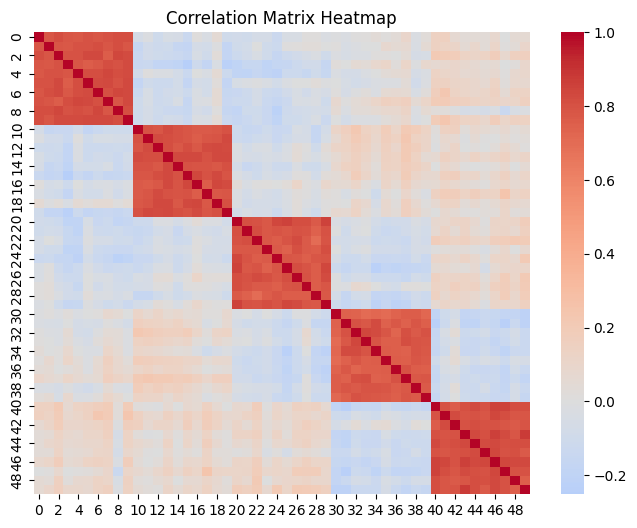

In [8]:
# Compute correlation matrix and heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to DataFrame
X_df = pd.DataFrame(X)

# Compute correlation matrix
corr_matrix = X_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()

1. The heatmap reveals five clear blocks of strong positive correlations along the diagonal, each corresponding to a group of 10 features. Within each block, correlations are high, while correlations between different blocks are close to zero. This pattern is consistent with the data-generating process, where features within a group share a common latent factor and features across groups are independent.

In [ ]:
git # Run PCA on the full dataset

# Fit PCA
pca_sim = PCA()
pca_sim.fit(X)

# Explained variance
explained_variance_ratio = pca_sim.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Number of components for 90%
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("Components needed for 90% variance:", n_components_90)

Components needed for 90% variance: 15


2. A total of 15 principal components are required to explain at least 90% of the total variance. Although the data were generated from five latent factors, additional components capture the independent noise added to each feature. Still, 15 components are substantially fewer than the original 50 features, indicating that PCA effectively reduces dimensionality in this dataset.

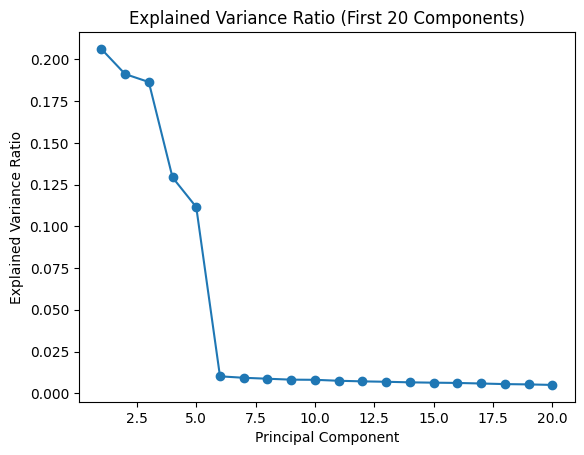

In [10]:
# Plot explained variance ratio
import matplotlib.pyplot as plt

plt.plot(range(1, 21), explained_variance_ratio[:20], marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio (First 20 Components)")
plt.show()

3. The explained variance curve shows a clear elbow around the fifth principal component. The first five components explain a large share of the variance, and after that the curve flattens, meaning each additional component adds only a small amount of new information. This suggests that the data has an underlying structure driven by about five main factors, which matches how the data were generated.

In [11]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [12]:
# Evaluate reconstruction error for different numbers of components
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import numpy as np

components_range = range(1, 31)

train_errors = []
test_errors = []

for k in components_range:
    pca_k = PCA(n_components=k)
    pca_k.fit(X_train)
    
    # Reconstruct train
    X_train_proj = pca_k.transform(X_train)
    X_train_recon = pca_k.inverse_transform(X_train_proj)
    train_error = mean_squared_error(X_train, X_train_recon)
    
    # Reconstruct test
    X_test_proj = pca_k.transform(X_test)
    X_test_recon = pca_k.inverse_transform(X_test_proj)
    test_error = mean_squared_error(X_test, X_test_recon)
    
    train_errors.append(train_error)
    test_errors.append(test_error)

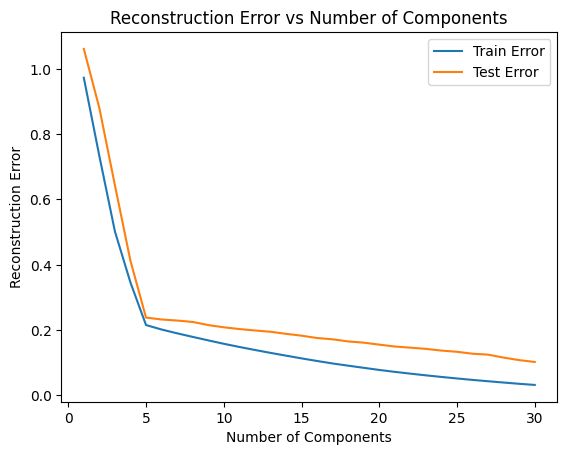

In [13]:
# plot errors

plt.plot(components_range, train_errors, label="Train Error")
plt.plot(components_range, test_errors, label="Test Error")
plt.xlabel("Number of Components")
plt.ylabel("Reconstruction Error")
plt.title("Reconstruction Error vs Number of Components")
plt.legend()
plt.show()

4. The reconstruction error decreases sharply up to about five components, after which the curve becomes much flatter. Both train and test errors follow a similar pattern and remain close, indicating good generalization. Based on the clear change in slope around five components, I would choose approximately five components to best summarize the dataset, as most of the meaningful structure is captured before that point.


## Task 3: PCA on uncorrelated features (4 points)

In this task you will simulate data where the data-generating process has **no correlations** between features (in math terms: the population covariance is the identity matrix).


In [14]:
# Data generation
import numpy as np

rng = np.random.default_rng(seed=20260218)  # for reproducibility
n = 100
p = 50
X = rng.normal(loc=0.0, scale=1.0, size=(n, p))  # population covariance = I_p

<div style="page-break-after: always"></div>

### Questions

1. Run PCA on the generated data (100 samples, 50 features). How many components are needed to explain at least 90% of the variance? Does this match your theoretical expectation given the data-generating process? (*Hint*: looking at the correlation heatmap like you did in the previous task could help.)

2. Split the data into an 80–20% train/test split. Fit PCA using the *train* set only. How many components are required to explain at least 90% of the variance on the training set? Compute the reconstruction error on the training set like we did in class and explain the result. Then, compute the reconstruction error on the test set and compare it to the training error.

3. For a range of component counts, compute reconstruction error on both train and test sets. Are the first few principal components equally effective on the test set as on the train set? Explain any differences.

4. Compare your findings across all three tasks: 
   - Task 1 (gene expression): high-dimensional real data
   - Task 2 (partial correlation): mixed structure
   - Task 3 (uncorrelated): no correlation structure  
   
   In which scenario is PCA most effective for dimensionality reduction? Explain why correlation structure matters for PCA's effectiveness.

In [ ]:
# Run PCA on uncorrelated data
pca_uncorr = PCA()
pca_uncorr.fit(X)

explained_variance_ratio = pca_uncorr.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("Components needed for 90% variance:", n_components_90)

Components needed for 90% variance: 34


1. A total of 34 principal components are required to explain at least 90% of the variance. Since the data were generated with no correlation between features and equal variance across dimensions, there is no strong underlying structure for PCA to capture. As expected, many components are needed to explain most of the variance, which confirms that PCA is not very effective for dimensionality reduction in this setting.

In [19]:
# Train-test split
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [20]:
# Fit PCA on training data
pca_train = PCA()
pca_train.fit(X_train)

explained_variance_ratio_train = pca_train.explained_variance_ratio_
cumulative_variance_train = np.cumsum(explained_variance_ratio_train)

n_components_90_train = np.argmax(cumulative_variance_train >= 0.90) + 1

print("Components needed for 90% variance (train set):", n_components_90_train)

Components needed for 90% variance (train set): 31


In [21]:
# Compute reconstruction error for training data using the number of components found above
# Use the number of components found above
pca_k = PCA(n_components=n_components_90_train)
pca_k.fit(X_train)

# Reconstruct training data
X_train_proj = pca_k.transform(X_train)
X_train_recon = pca_k.inverse_transform(X_train_proj)

train_error = mean_squared_error(X_train, X_train_recon)
print("Training reconstruction error:", train_error)

Training reconstruction error: 0.09011903285843781


In [22]:
# Reconstruct test data using PCA fitted on training set
X_test_proj = pca_k.transform(X_test)
X_test_recon = pca_k.inverse_transform(X_test_proj)

test_error = mean_squared_error(X_test, X_test_recon)
print("Test reconstruction error:", test_error)

Test reconstruction error: 0.5035032961481251


2. When PCA is fitted on the training set, 31 components are required to explain 90% of the variance, which is a large number given that the data contain no underlying correlation structure. The reconstruction error on the training set is low (0.09), since PCA can closely approximate the training data when many components are used. However, the test reconstruction error is substantially higher (0.50), indicating that the principal components capture sample-specific noise rather than stable structure. This confirms that PCA does not generalize well in the absence of true correlations.

3. When reconstruction errors are computed for a range of component counts, the training error decreases steadily as more components are included. However, the test error remains substantially higher, particularly for smaller numbers of components. This shows that the first few principal components are not equally effective on the test set, as they mainly capture sample-specific variation in the training data rather than stable underlying structure. The difference between train and test performance reflects the fact that the data contain no true correlation structure for PCA to exploit.

4. PCA is most effective in Task 2, where the data contain a clear correlation structure driven by a small number of latent factors. In that case, most of the variance is concentrated in the first few principal components, allowing substantial dimensionality reduction. In Task 1, PCA shows moderate effectiveness, as real-world gene expression data contain some structure but also considerable noise. In contrast, PCA is least effective in Task 3, where the features are independent and variance is evenly distributed across dimensions. Correlation structure matters because PCA relies on shared variation between features; without correlation, there are no dominant directions of variance to exploit, and dimensionality reduction becomes limited.